**Importing Libraries**

In [7]:
import pandas as pd
import seaborn as sns
import numpy as np
import itertools 

import matplotlib
import matplotlib.pyplot as plt
plt.style.use('ggplot') # standard plot that will be use
from matplotlib.pyplot import figure
from matplotlib.lines import Line2D

%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12, 8) # Standart adjusts plot configuration


**Importing Data & Quick Analysis**

In [8]:
df = pd.read_csv(r'stores_sales_forecasting.csv', encoding = 'latin-1')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         2121 non-null   int64  
 1   Order ID       2121 non-null   object 
 2   Order Date     2121 non-null   object 
 3   Ship Date      2121 non-null   object 
 4   Ship Mode      2121 non-null   object 
 5   Customer ID    2121 non-null   object 
 6   Customer Name  2121 non-null   object 
 7   Segment        2121 non-null   object 
 8   Country        2121 non-null   object 
 9   City           2121 non-null   object 
 10  State          2121 non-null   object 
 11  Postal Code    2121 non-null   int64  
 12  Region         2121 non-null   object 
 13  Product ID     2121 non-null   object 
 14  Category       2121 non-null   object 
 15  Sub-Category   2121 non-null   object 
 16  Product Name   2121 non-null   object 
 17  Sales          2121 non-null   float64
 18  Quantity

In [10]:
# new columns names

col_names = ['id',
             'order_id',
             'order_date',
             'ship_date',
             'ship_mode',
             'customer_id',
             'customer_name',
             'segment',
             'country',
             'city',
             'state',
             'postal_code',
             'region',
             'product_id',
             'category',
             'sub-category',
             'product_name',
             'vl_unit',
             'qtd',
             'discount',
             'profit']

df.columns = col_names


In [11]:
df.head()

,id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,sub-category,product_name,vl_unit,qtd,discount,profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092


In [12]:
df.dtypes

id                 int64
order_id          object
order_date        object
ship_date         object
ship_mode         object
customer_id       object
customer_name     object
segment           object
country           object
city              object
state             object
postal_code        int64
region            object
product_id        object
category          object
sub-category      object
product_name      object
vl_unit          float64
qtd                int64
discount         float64
profit           float64
dtype: object

In [13]:
# fixing data types

df['id'] = df['id'].astype('object')
df['order_date'] = pd.to_datetime(df['order_date'], errors = 'coerce')
df['ship_date'] = pd.to_datetime(df['ship_date'], errors = 'coerce')

df.dtypes

id                       object
order_id                 object
order_date       datetime64[ns]
ship_date        datetime64[ns]
ship_mode                object
customer_id              object
customer_name            object
segment                  object
country                  object
city                     object
state                    object
postal_code               int64
region                   object
product_id               object
category                 object
sub-category             object
product_name             object
vl_unit                 float64
qtd                       int64
discount                float64
profit                  float64
dtype: object

In [14]:
# creating columns

df['revenue'] = df['vl_unit'] * (1 - df['discount']) * df['qtd']
df['cost'] = df['revenue'] - df['profit']
df['profit_margin_dec'] = (df['revenue'] - df['cost']) / df['revenue']
df['profit_margin_perc'] = df['profit_margin_dec'] * 100
df['discount_perc'] = df['discount'] * 100
df['year'] = df['order_date'].dt.year

df.head()

,id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,vl_unit,qtd,discount,profit,revenue,cost,profit_margin_dec,profit_margin_perc,discount_perc,year
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,261.9600,2,0.00,41.9136,523.920000,482.006400,0.080000,8.000000,0.0,2016
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,731.9400,3,0.00,219.5820,2195.820000,1976.238000,0.100000,10.000000,0.0,2016
2,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,957.5775,5,0.45,-383.0310,2633.338125,3016.369125,-0.145455,-14.545455,45.0,2015
3,6,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,48.8600,7,0.00,14.1694,342.020000,327.850600,0.041429,4.142857,0.0,2014
4,11,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,1706.1840,9,0.20,85.3092,12284.524800,12199.215600,0.006944,0.694444,20.0,2014


In [15]:
# describe data

df.describe()

,order_date,ship_date,postal_code,vl_unit,qtd,discount,profit,revenue,cost,profit_margin_dec,profit_margin_perc,discount_perc,year
count,2121,2121,2121.000000,2121.000000,2121.000000,2121.000000,2121.000000,2121.000000,2121.000000,2121.000000,2121.000000,2121.000000,2121.000000
mean,2016-04-30 03:54:13.748231680,2016-05-04 01:54:44.299858432,55726.556341,349.834887,3.785007,0.173923,8.699327,1522.566978,1513.867651,-0.029299,-2.929933,17.392268,2015.713343
min,2014-01-06 00:00:00,2014-01-10 00:00:00,1040.000000,1.892000,1.000000,0.000000,-1862.312400,0.756800,1.542300,-5.222222,-522.222222,0.000000,2014.000000
25%,2015-05-26 00:00:00,2015-05-31 00:00:00,22801.000000,47.040000,2.000000,0.000000,-12.849000,99.967500,101.304000,-0.031250,-3.125000,0.000000,2015.000000
50%,2016-06-20 00:00:00,2016-06-23 00:00:00,60505.000000,182.220000,3.000000,0.200000,7.774800,408.844800,419.538600,0.035156,3.515625,20.000000,2016.000000
75%,2017-05-14 00:00:00,2017-05-18 00:00:00,90032.000000,435.168000,5.000000,0.300000,33.726600,1364.947200,1375.448000,0.085937,8.593750,30.000000,2017.000000
max,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,4416.174000,14.000000,0.700000,1013.127000,34664.140800,35383.935600,0.480000,48.000000,70.000000,2017.000000
std,NaN,NaN,32261.888225,503.179145,2.251620,0.181547,136.049246,3339.823554,3305.245410,0.315069,31.506926,18.154728,1.117551


**Analysis**

Correlation Analysis

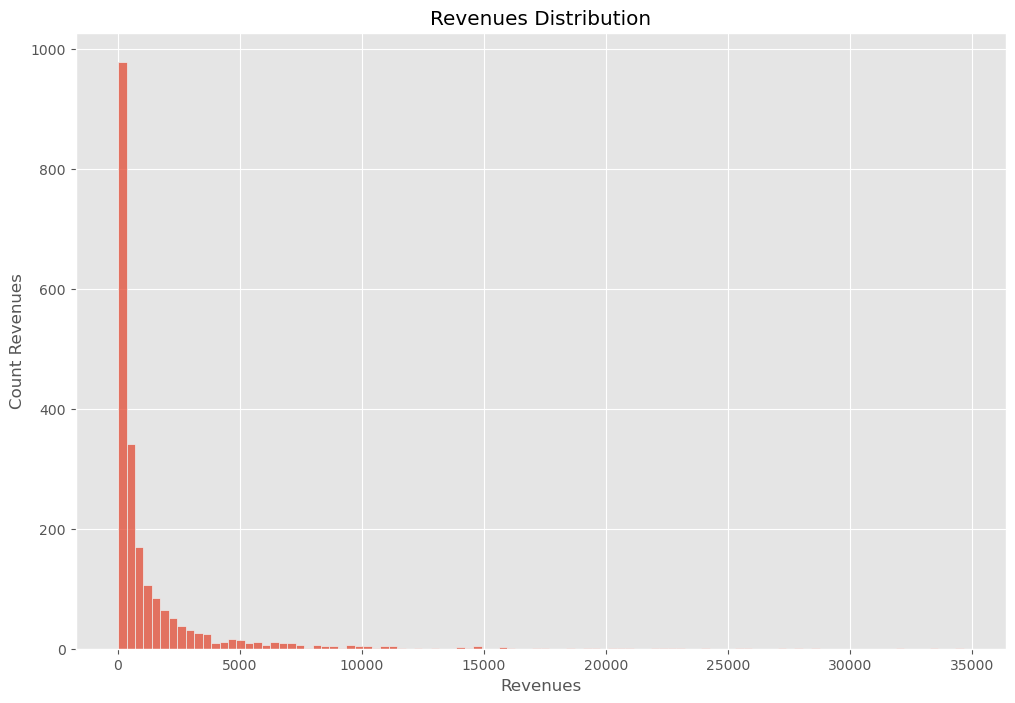

In [16]:
# revenues distribution

sns.histplot(
    x = 'revenue',
    data = df,
    bins = 100
)

plt.title('Revenues Distribution')

plt.ylabel('Count Revenues')
plt.xlabel('Revenues')

plt.show()

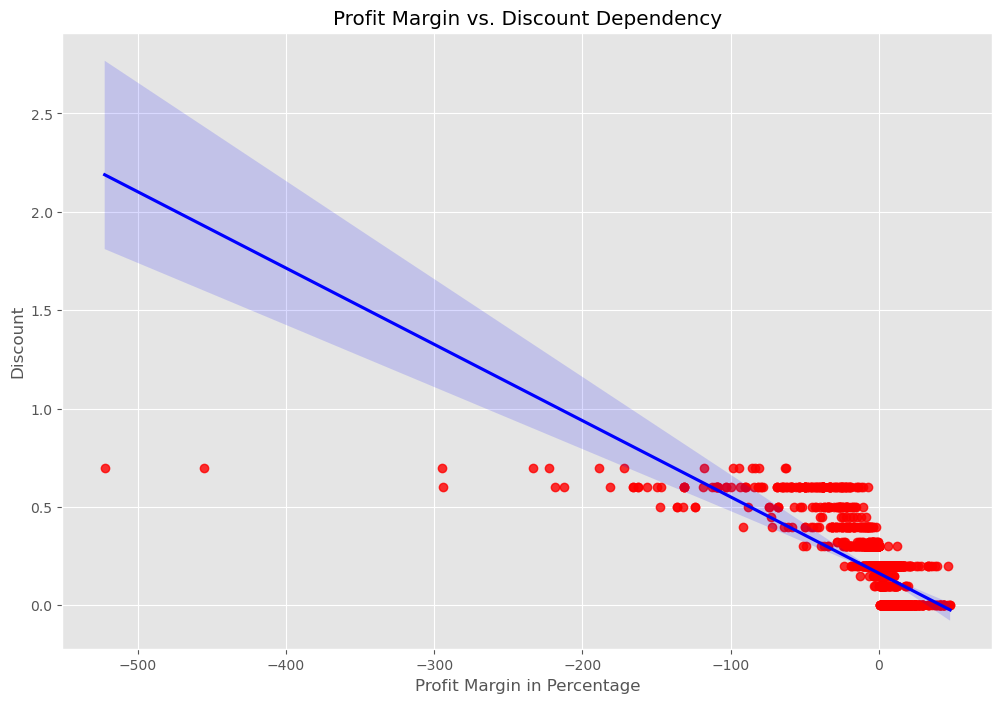

In [17]:
# Revenues vs. Profit

sns.regplot(
    x = 'profit_margin_perc',
    y = 'discount',
    data = df,
    scatter_kws = {'color': 'red'},
    line_kws = {'color': 'blue'}
)

plt.title('Profit Margin vs. Discount Dependency')

plt.ylabel('Discount')
plt.xlabel('Profit Margin in Percentage')

plt.show()

In [18]:
# correlation Matriz

df_corr = df.corr(numeric_only = True)

df_corr

,postal_code,vl_unit,qtd,discount,profit,revenue,cost,profit_margin_dec,profit_margin_perc,discount_perc,year
postal_code,1.000000,-0.011786,0.013700,0.106736,-0.026335,-0.019978,-0.019103,-0.103972,-0.103972,0.106736,-0.016405
vl_unit,-0.011786,1.000000,0.437464,-0.028576,0.173510,0.908577,0.910941,0.041474,0.041474,-0.028576,-0.047660
qtd,0.013700,0.437464,1.000000,-0.015695,0.061213,0.567718,0.571137,0.040112,0.040112,-0.015695,-0.052997
discount,0.106736,-0.028576,-0.015695,1.000000,-0.483769,-0.096376,-0.077471,-0.673178,-0.673178,1.000000,-0.017077
profit,-0.026335,0.173510,0.061213,-0.483769,1.000000,0.273211,0.234908,0.248943,0.248943,-0.483769,-0.017445
revenue,-0.019978,0.908577,0.567718,-0.096376,0.273211,1.000000,0.999216,0.050685,0.050685,-0.096376,-0.053659
cost,-0.019103,0.910941,0.571137,-0.077471,0.234908,0.999216,1.000000,0.040968,0.040968,-0.077471,-0.053503
profit_margin_dec,-0.103972,0.041474,0.040112,-0.673178,0.248943,0.050685,0.040968,1.000000,1.000000,-0.673178,-0.012398
profit_margin_perc,-0.103972,0.041474,0.040112,-0.673178,0.248943,0.050685,0.040968,1.000000,1.000000,-0.673178,-0.012398
discount_perc,0.106736,-0.028576,-0.015695,1.000000,-0.483769,-0.096376,-0.077471,-0.673178,-0.673178,1.000000,-0.017077


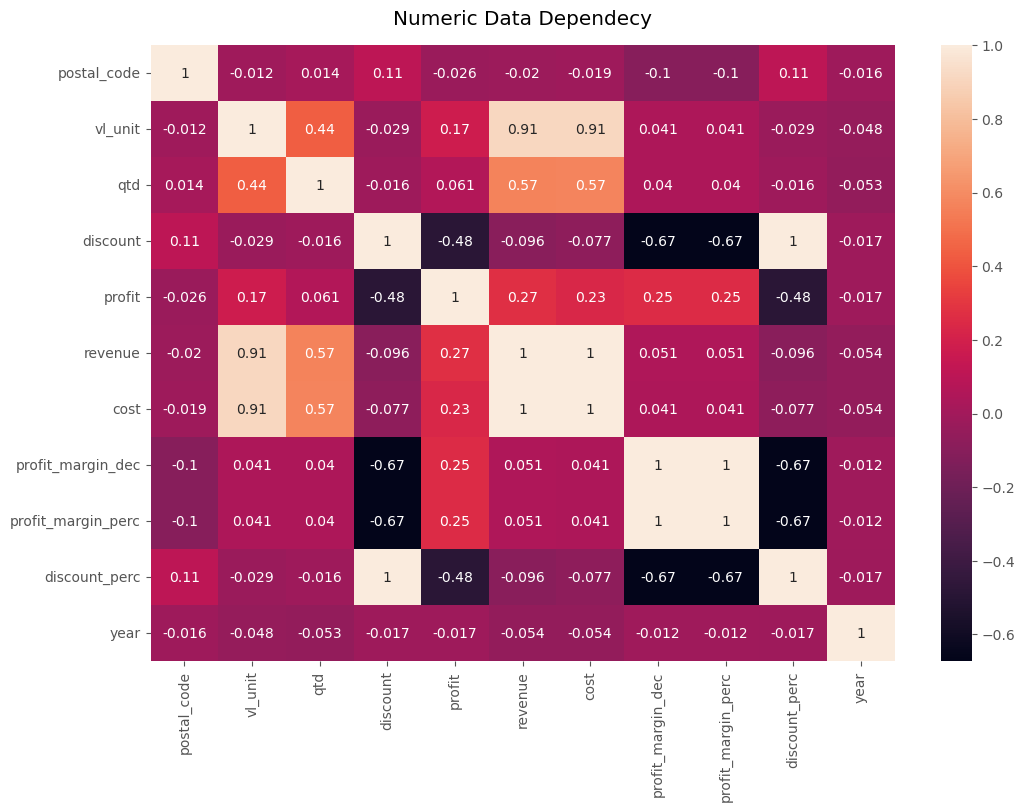

In [66]:
# correlation matriz plot

sns.heatmap(
    data = df_corr,
    annot = True
)

plt.title('Numeric Data Dependecy', y = 1.02)

plt.show()

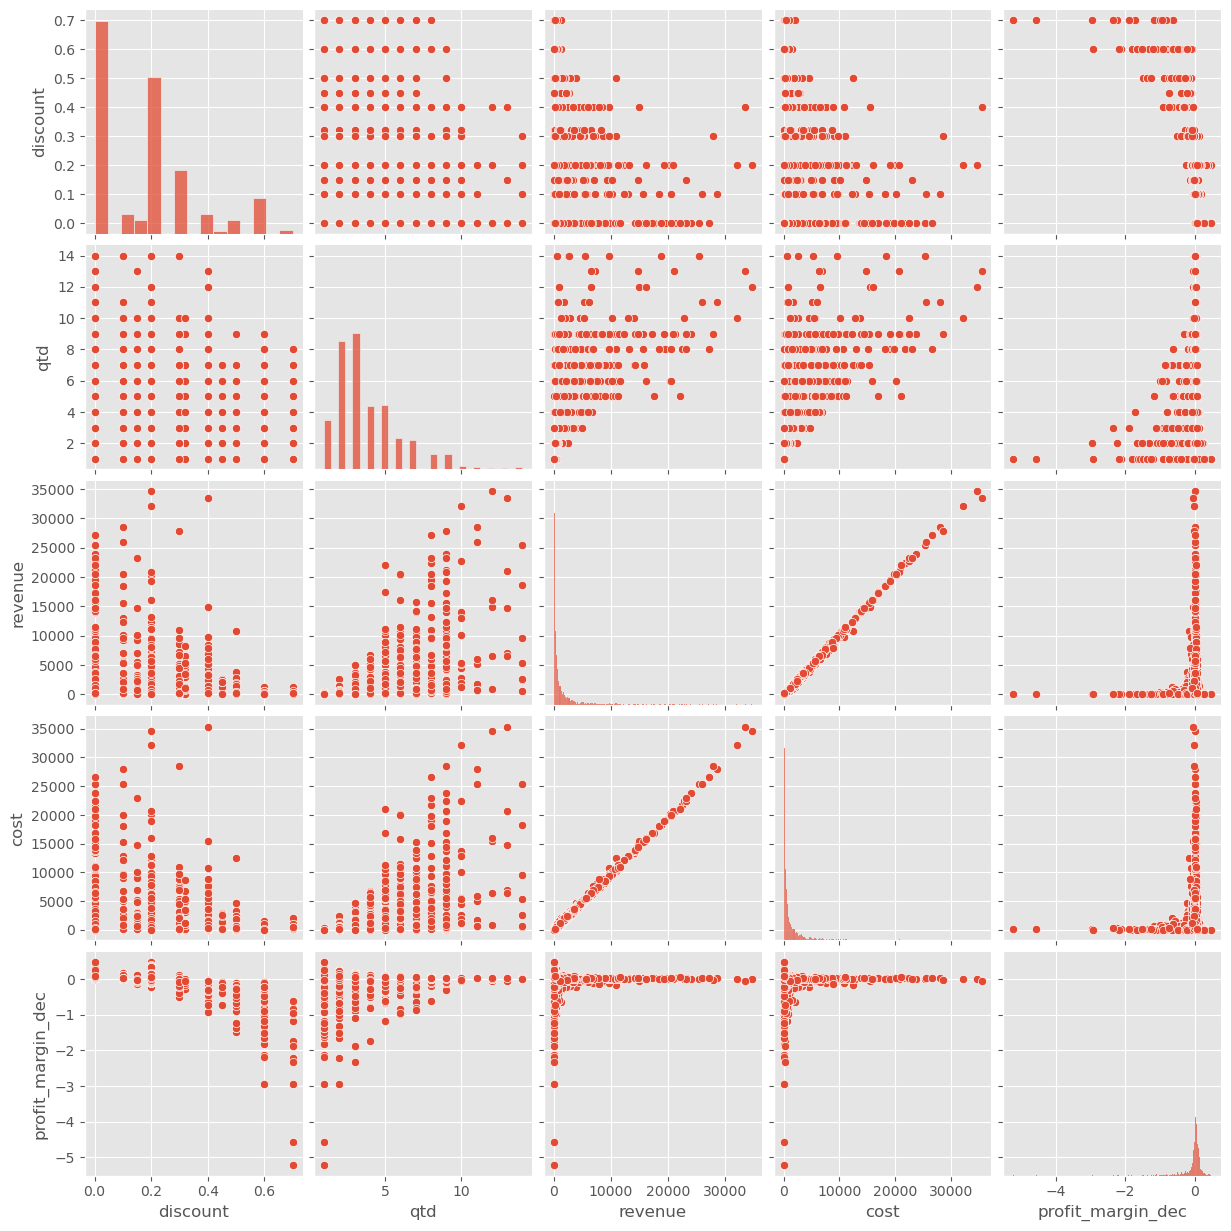

In [20]:
sns.pairplot(
    data = df,
    vars = ['discount', 'qtd', 'revenue', 'cost', 'profit_margin_dec']
)

plt.show()

Revenue and Profit Behavior by Discounts Applied

In [21]:
df_desc_low_rev = df.groupby(by = ['discount'])[['revenue', 'profit', 'profit_margin_perc']].mean()

print(df_desc_low_rev)

              revenue      profit  profit_margin_perc
discount                                             
0.00      1643.203672   69.537173           10.605082
0.10      3415.868372   93.565946            5.363270
0.15      2396.789960   27.288298            1.119547
0.20      1366.571447   10.188535            3.407069
0.30      1479.440446  -48.177103           -6.645198
0.32      1878.385770  -88.560656           -9.586832
0.40      2268.040560 -215.831957          -22.792284
0.45      1240.438650 -226.646464          -26.877750
0.50       954.877870 -238.355537          -46.016226
0.60        90.072893  -43.077212          -62.624098
0.70       271.483320 -259.662627         -185.016755


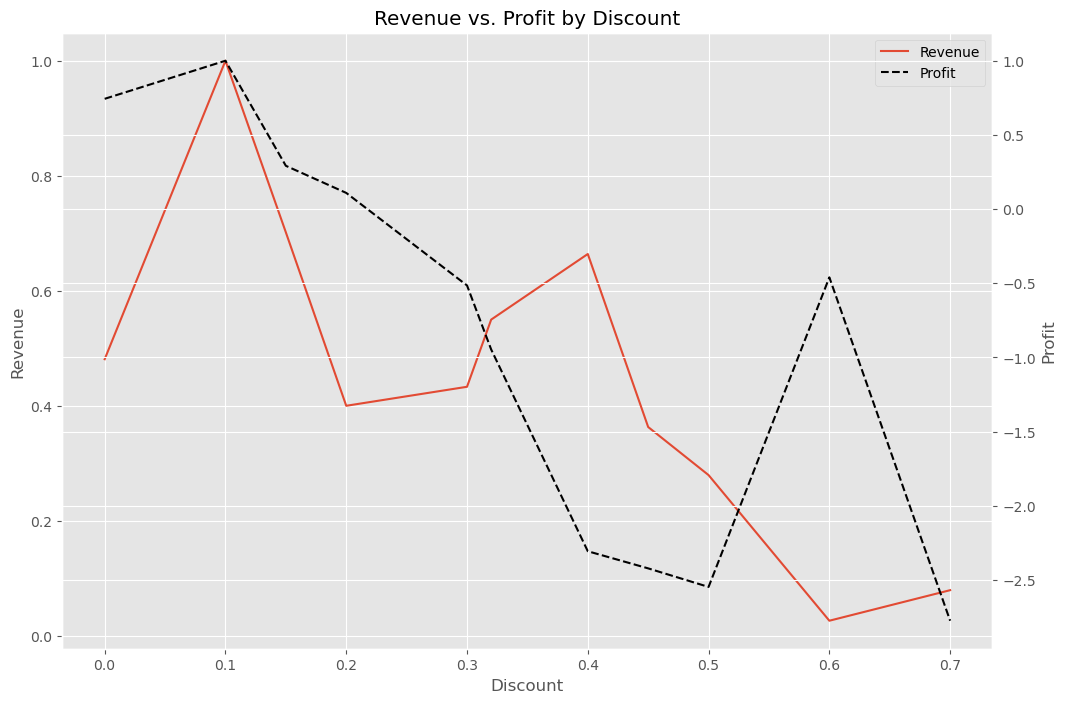

In [22]:
# Revenue vs Profit by Discount
df_desc_low_rev_norm = df_desc_low_rev.copy()

for col in ['revenue', 'profit', 'profit_margin_perc']:
    df_desc_low_rev_norm[col] = df_desc_low_rev_norm[col] / df_desc_low_rev_norm[col].max()

fig, ax1 = plt.subplots()

# Revenue Line Plot
line1 = sns.lineplot(
    data = df_desc_low_rev_norm,
    x = 'discount',
    y = 'revenue',
    ax = ax1,
    legend = False
)

ax2 = ax1.twinx()

#Profit Line Plot
line2 = sns.lineplot(
    data = df_desc_low_rev_norm,
    x = 'discount',
    y = 'profit',
    ax = ax2,
    linestyle = '--',
    color = 'black',
    legend = False
)

ax1.set_xlabel('Discount')
ax1.set_ylabel('Revenue')
ax2.set_ylabel('Profit')

line1 = ax1.lines[0]
line2 = ax2.lines[0]

ax1.legend([line1, line2], ['Revenue', 'Profit'], loc = 'best')

plt.title('Revenue vs. Profit by Discount')

plt.show()

Discounts Behavior by Sub-Category

In [23]:
df.columns

Index(['id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id',
       'customer_name', 'segment', 'country', 'city', 'state', 'postal_code',
       'region', 'product_id', 'category', 'sub-category', 'product_name',
       'vl_unit', 'qtd', 'discount', 'profit', 'revenue', 'cost',
       'profit_margin_dec', 'profit_margin_perc', 'discount_perc', 'year'],
      dtype='object')

In [24]:
df_sub_cat = df.groupby(by = ['discount', 'sub-category'])[['revenue', 'profit', 'profit_margin_perc']].mean().reset_index()

print(df_sub_cat)

    discount sub-category      revenue      profit  profit_margin_perc
0       0.00    Bookcases  2616.981000  101.261862            7.896832
1       0.00       Chairs  3732.713459  164.910497            8.372800
2       0.00  Furnishings   551.280490   29.506075           11.890037
3       0.00       Tables  5631.491111  184.393051            6.795076
4       0.10       Chairs  3415.868372   93.565946            5.363270
5       0.15    Bookcases  2396.789960   27.288298            1.119547
6       0.20    Bookcases  2485.907896    2.837004           -0.392768
7       0.20       Chairs  1704.858880   17.132700            1.022753
8       0.20  Furnishings   349.227432    8.692863            7.486724
9       0.20       Tables  3003.754276   -4.275465            0.014348
10      0.30    Bookcases  1550.090500  -55.587260           -5.713152
11      0.30       Chairs  1528.868972  -42.639979           -6.366449
12      0.30       Tables  1321.732896  -63.006067           -7.633400
13    

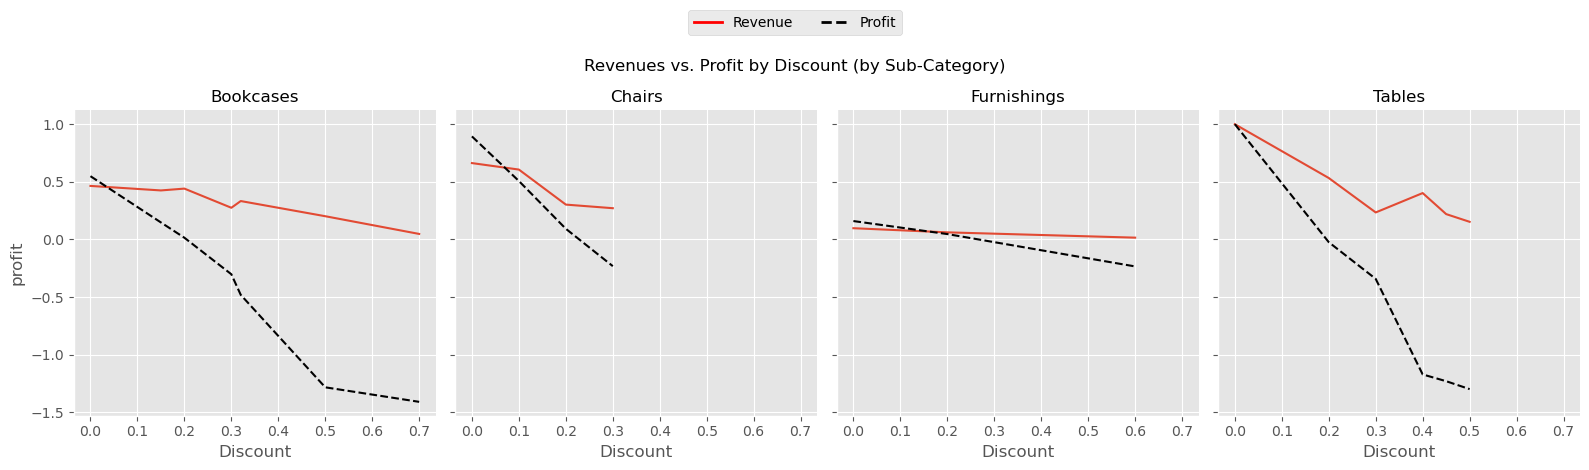

In [25]:
# normalize data
df_sub_cat_norm = df_sub_cat.copy()

for col in ['revenue', 'profit', 'profit_margin_perc']:
    df_sub_cat_norm[col] = df_sub_cat_norm[col] / df_sub_cat_norm[col].max()

# FaceiGrid
g = sns.FacetGrid(
    data = df_sub_cat_norm,
    col = 'sub-category',
    height = 4
)

# Revenue
g.map_dataframe(
    sns.lineplot,
    x = 'discount',
    y = 'revenue',
    legend = False
)

# Profit
g.map_dataframe(
    sns.lineplot,
    x = 'discount',
    y = 'profit',
    linestyle = '--',
    color = 'black',
    legend = False
)

g.set_axis_labels('Discount')
g.set_titles('{col_name}')

legend_lines = [
    Line2D([0], [0], color='red', lw=2),
    Line2D([0], [0], color='black', lw=2, linestyle='--')
]

g.fig.legend(
    legend_lines,
    ['Revenue', 'Profit'],
    loc='upper center',
    bbox_to_anchor=(0.5, 1.18),
    ncol=2
)

plt.suptitle('Revenues vs. Profit by Discount (by Sub-Category)', y = 1.04)

plt.show()

Discount Behavior by Region

In [26]:
df_region = df.groupby(by = ['discount', 'region'])[['revenue', 'profit', 'profit_margin_perc']].mean()

print(df_region)

                      revenue      profit  profit_margin_perc
discount region                                              
0.00     Central  2614.171346  106.675525            9.385683
         East     1082.390841   56.232798           11.652073
         South    2240.561438   92.007995            9.280812
         West     1234.004694   47.829262           11.167972
0.10     East     3415.868372   93.565946            5.363270
0.15     West     2396.789960   27.288298            1.119547
0.20     East     1002.831234    8.102151            5.392385
         South     750.452524    6.142798            4.719870
         West     1796.413990   12.880298            1.967218
0.30     Central  1357.201620  -48.358406           -6.631319
         East     1696.414361  -47.855290           -6.669835
0.32     Central  1878.385770  -88.560656           -9.586832
0.40     East     1593.284766 -166.775069          -24.961831
         South    4756.202550 -396.729231          -14.792080
0.45    

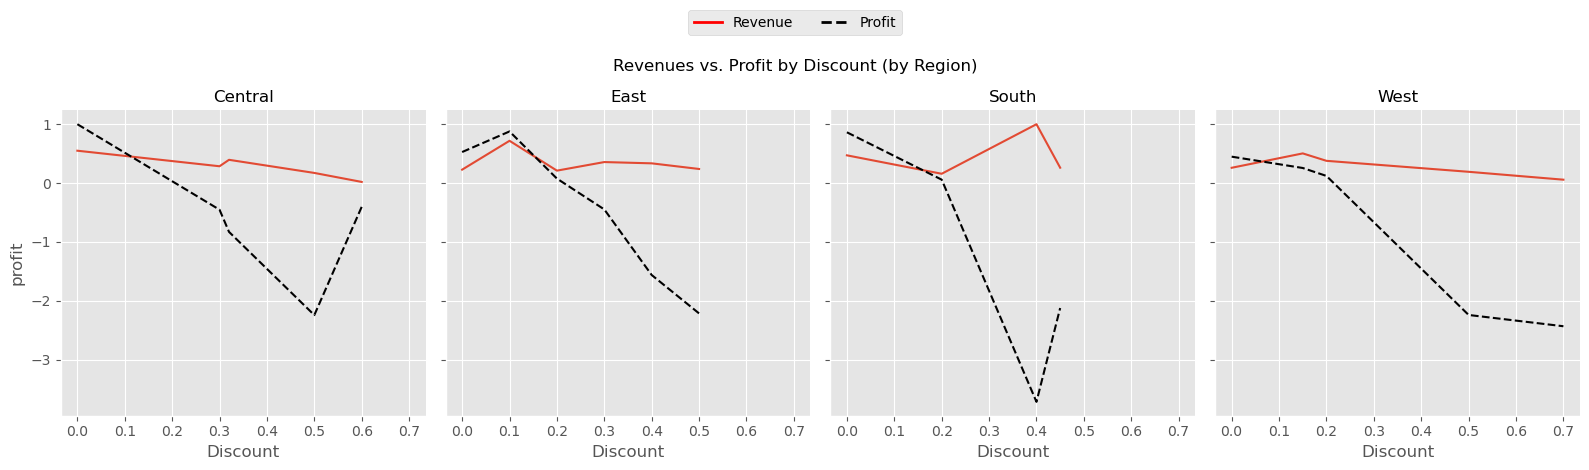

In [27]:
# normalize data

df_region_norm = df_region.copy().reset_index()

for col in ['revenue', 'profit', 'profit_margin_perc']:
    df_region_norm[col] = df_region_norm[col] / df_region_norm[col].max()

# FaceGrid
g = sns.FacetGrid(
    data = df_region_norm,
    col = 'region',
    height = 4
)

# revenue
g.map_dataframe(
    sns.lineplot,
    x = 'discount',
    y = 'revenue',
    legend = False
)

# profit
g.map_dataframe(
    sns.lineplot,
    x = 'discount',
    y = 'profit',
    linestyle = '--',
    color = 'black',
    legend = False
)

g.set_axis_labels('Discount')
g.set_titles('{col_name}')

legend_lines = [
    Line2D([0], [0], color='red', lw=2),
    Line2D([0], [0], color='black', lw=2, linestyle='--')
]

g.fig.legend(
    legend_lines,
    ['Revenue', 'Profit'],
    loc='upper center',
    bbox_to_anchor=(0.5, 1.18),
    ncol=2
)

plt.suptitle('Revenues vs. Profit by Discount (by Region)', y = 1.04)

plt.show()

What-If Scenario Analysis

In [28]:
# current reality

revenue = df['revenue'].sum() # Total revenues
profit = df['profit'].sum() # Total profits
Qtd = df['qtd'].sum() # Total Quantity

weighted_discount = (
    (df['discount'] * df['revenue']).sum() / df['revenue'].sum() # return the weighted discounts
)

#It's reflect the real business impact (Big sales have more importance)


In [ ]:
# Approach for the test:
# Target discount levels will be apply using a combination of the sub-category and region results
# Discounts should be applied selectively and experimentally, as current patterns show no consistent financial benefit.

In [30]:
# target discount

target_discount = 0

# sub-categorie discounts
sub_category = {
    'Bookcases' : 0.10,
    'Chairs': 0.15,
    'Furnishings': 0.20,
    'Tables': 0.15
}

region = {
    'Central': 0.20,
    'East': 0.20,
    'South': 0.20,
    'West': 0.15
}

combinations = list(itertools.product(sub_category.keys(), region.keys()))

combinations = pd.DataFrame(combinations, columns = ['sub-category', 'region'])

combinations['discount_target'] = combinations.apply(
    lambda row: min(sub_category[row['sub-category']], region[row['region']]),
    axis = 1
)

In [31]:
# Simulation

# price change
df_simulation = df.copy()

df_simulation = df_simulation.merge(
    combinations,
    on=['sub-category', 'region'],
    how='left'
)

df_simulation['discount_target'] = df_simulation[['discount', 'discount_target']].min(axis=1)

df_simulation

df_simulation['price_before'] = df_simulation['vl_unit'] * (1 - df_simulation['discount'])
df_simulation['price_after'] = df_simulation['vl_unit'] * (1 - df_simulation['discount_target'])

df_simulation['price_change_perc'] = (
    (df_simulation['price_after'] - df_simulation['price_before']) / df_simulation['price_before']
)

# elasticity and new quantity
elasticity = -1.0 # it allow to simulate the demand sensitivity adjustament under differents discount scenarios
#elasticity = -0.5
#elasticity = -1.5

df_simulation['new_qtd'] = df_simulation['qtd'] * np.exp(elasticity * df_simulation['price_change_perc'])
df_simulation['new_qtd'] = df_simulation['new_qtd'].clip(lower = 0) # avoid negativie quantities

# new cost
df_simulation['unit_cost'] = df_simulation['cost'] / df_simulation['qtd']
df_simulation['new_cost'] = df_simulation['unit_cost'] * df_simulation['new_qtd']

# new revenue
df_simulation['new_revenue'] = df_simulation['price_after'] * df_simulation['new_qtd']

#new profit
df_simulation['new_profit'] = df_simulation['new_revenue'] - df_simulation['new_cost']

In [32]:
pd.set_option('display.max_columns', None)

df_simulation

,id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub-category,product_name,vl_unit,qtd,discount,profit,revenue,cost,profit_margin_dec,profit_margin_perc,discount_perc,year,discount_target,price_before,price_after,price_change_perc,new_qtd,unit_cost,new_cost,new_revenue,new_profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,523.920000,482.006400,0.080000,8.000000,0.0,2016,0.00,261.960000,261.960000,0.000000,2.000000,241.003200,482.006400,523.920000,41.913600
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2195.820000,1976.238000,0.100000,10.000000,0.0,2016,0.00,731.940000,731.940000,0.000000,3.000000,658.746000,1976.238000,2195.820000,219.582000
2,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2633.338125,3016.369125,-0.145455,-14.545455,45.0,2015,0.15,526.667625,813.940875,0.545455,2.897891,603.273825,1748.222026,2358.712257,610.490231
3,6,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694,342.020000,327.850600,0.041429,4.142857,0.0,2014,0.00,48.860000,48.860000,0.000000,7.000000,46.835800,327.850600,342.020000,14.169400
4,11,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092,12284.524800,12199.215600,0.006944,0.694444,20.0,2014,0.15,1364.947200,1450.256400,0.062500,8.454718,1355.468400,11460.102491,12261.508259,801.405769
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2116,9963,CA-2015-168088,2015-03-19,2015-03-22,First Class,CM-12655,Corinna Mitchell,Home Office,United States,Houston,Texas,77041,Central,FUR-BO-10004218,Furniture,Bookcases,Bush Heritage Pine Collection 5-Shelf Bookcase...,383.4656,4,0.32,-67.6704,1043.026432,1110.696832,-0.064879,-6.487889,32.0,2015,0.10,260.756608,345.119040,0.323529,2.894363,277.674208,803.689871,998.899677,195.209806
2117,9965,CA-2016-146374,2016-12-05,2016-12-10,Second Class,HE-14800,Harold Engle,Corporate,United States,Newark,Delaware,19711,East,FUR-FU-10002671,Furniture,Furnishings,Electrix 20W Halogen Replacement Bulb for Zoom...,13.4000,1,0.00,6.4320,13.400000,6.968000,0.480000,48.000000,0.0,2016,0.00,13.400000,13.400000,0.000000,1.000000,6.968000,6.968000,13.400000,6.432000
2118,9981,US-2015-151435,2015-09-06,2015-09-09,Second Class,SW-20455,Shaun Weien,Consumer,United States,Lafayette,Louisiana,70506,South,FUR-TA-10001039,Furniture,Tables,KI Adjustable-Height Table,85.9800,1,0.00,22.3548,85.980000,63.625200,0.260000,26.000000,0.0,2015,0.00,85.980000,85.980000,0.000000,1.000000,63.625200,63.625200,85.980000,22.354800
2119,9990,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,Florida,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028,60.595200,56.492400,0.067708,6.770833,20.0,2014,0.20,20.198400,20.198400,0.000000,3.000000,18.830800,56.492400,60.595200,4.102800


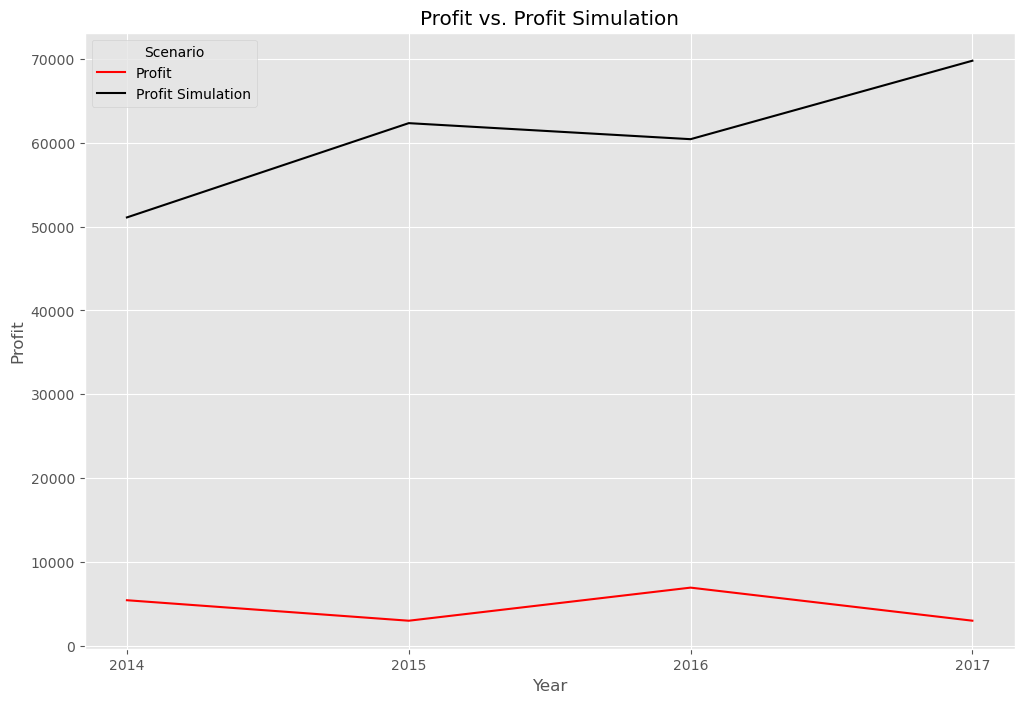

In [33]:
# Profit vs. Profit Simulation

# year aggregation
df_year = df_simulation.groupby('year').agg({
    'profit': 'sum',
    'new_profit': 'sum'
}).reset_index()

df_year_melt = df_year.melt(
    id_vars = 'year',
    value_vars = ['profit', 'new_profit'],
    var_name = 'scenario',
    value_name = 'value'
)

# simulation profit graphic
sns.lineplot(
    data = df_year_melt,
    x = 'year',
    y = 'value',
    hue = 'scenario', 
    palette = ['red', 'black'],
    markers = True
)

plt.xlabel('Year')
plt.ylabel('Profit')

handles, labels = plt.gca().get_legend_handles_labels()

labels = ['Profit', 'Profit Simulation']

plt.legend(title = 'Scenario', handles = handles, labels = labels, loc = 'best')

plt.title('Profit vs. Profit Simulation')

plt.xticks(df_year_melt['year'].unique())

plt.show()

In [ ]:
df_year = df_simulation.groupby('year')[['profit', 'new_profit']].sum()

df_year['dif'] = (df_year['new_profit'] / df_year['profit']).astype(int)

print(df_year)


         profit    new_profit  dif
year                              
2014  5457.7255  51091.922859    9
2015  3015.2029  62329.529424   20
2016  6959.9531  60418.578516    8
2017  3018.3913  69771.136686   23
